# Baseline Experiment: Comparison of supervised and unsupervised CAE

This notebook evaluates only the **baseline experiment**.

It compares the unsupervised and supervised CAE by their performance on the reconstruction and classification task.

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = "../results/raw_results.json"

sns.set(style="whitegrid")

with open(PATH, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Keep only relevant columns
df = df[[
    "dataset",
    "subset",
    "reconstruction_mse",
    "accuracy"
]]

df_grouped = (
    df
    .groupby(["dataset", "subset"])
    .mean(numeric_only=True)
    .reset_index()
)

## Table Classification Accuracy

In [15]:
classification_table = df_grouped.pivot(
    index="dataset",
    columns="subset",
    values="accuracy"
)

print("\n=== Classification Accuracy ===")
print(classification_table.round(4))


=== Classification Accuracy ===
subset         supervised_cae  unsupervised_cae
dataset                                        
activity               0.9213            0.9063
coil20                 0.4997            0.4910
fashion_mnist          0.8043            0.7957
isolet                 0.8433            0.8028
mice_protein           0.6306            0.5972
mnist                  0.8736            0.8649


## Table Regression Error

In [16]:
reconstruction_table = df_grouped.pivot(
    index="dataset",
    columns="subset",
    values="reconstruction_mse"
)

print("\n=== Reconstruction MSE ===")
print(reconstruction_table.round(4))


=== Reconstruction MSE ===
subset         supervised_cae  unsupervised_cae
dataset                                        
activity         4.459000e-01            0.2753
coil20           3.290096e+06            0.4851
fashion_mnist    2.240000e-02            0.0194
isolet           4.850000e-01            0.4062
mice_protein     4.255000e-01            0.4442
mnist            2.360000e-02            0.0194


## Plot Classification Accuracy

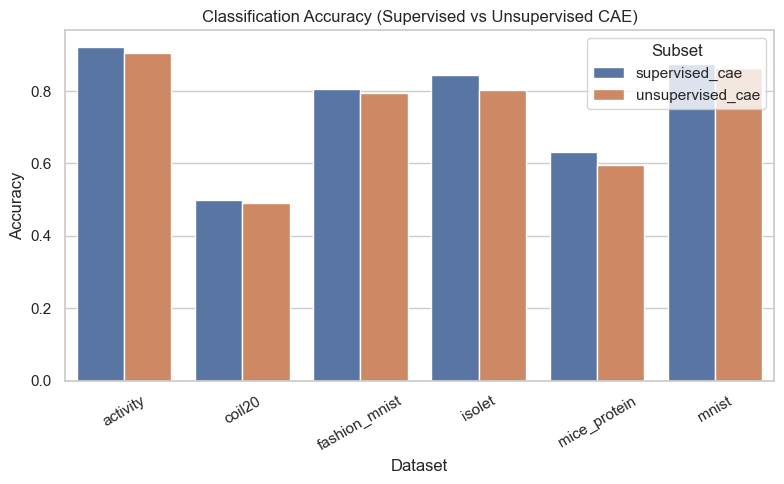

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_grouped,
    x="dataset",
    y="accuracy",
    hue="subset"
)

plt.title("Classification Accuracy (Supervised vs Unsupervised CAE)")
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.xticks(rotation=30)
plt.legend(title="Subset")
plt.tight_layout()
plt.show()

## Plot Reconstruction Error

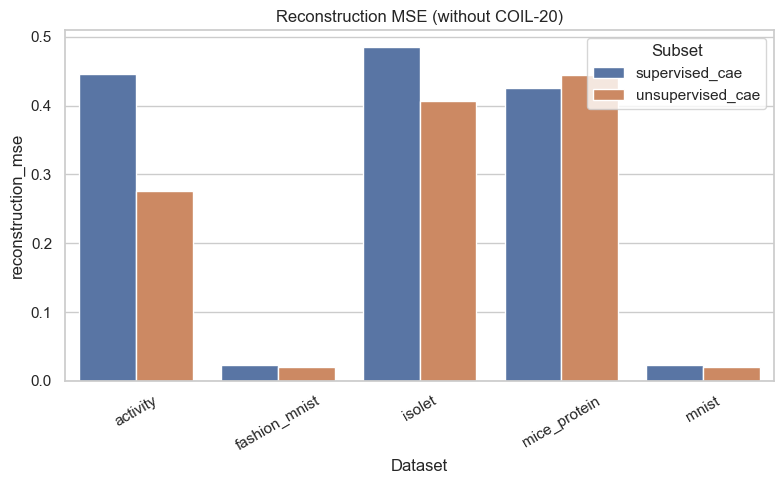

In [21]:
df_plot = df_grouped[df_grouped["dataset"] != "coil20"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_plot,
    x="dataset",
    y="reconstruction_mse",
    hue="subset"
)

plt.title("Reconstruction MSE (without COIL-20)")
plt.ylabel("reconstruction_mse")
plt.xlabel("Dataset")
plt.xticks(rotation=30)
plt.legend(title="Subset")
plt.tight_layout()
plt.show()